# Типизация и аннотации

## **Dynamic typing**

Проверяется тип аргумента в Runtime. Тип ассоциирован с объектом

In [ ]:
def f(a):
    # print(a + 10)  # Throws TypeError
    a.some_func()  # Throws AttributeError

def g():
    print("Runtime")
    f("hello")

g()

Runtime


AttributeError: 'str' object has no attribute 'some_func'

А если я хочу понять, какого типа переменная?

- **посмотреть код** - по именам переменных и некоторым операциям с ними можно понять что за тип используется

In [ ]:
def func1(l): # раз l - то возможно это список
    # new_list - точно список, т.к. list comprehension + имя
    # более того, это скорее всего список чисел, но это не точно
    new_list = [item for item in l if item > 10]

- **`print(type(var))` / использовать дебаггер** - попросить Python явно вывести какой тип используется при работе программы

В целом оба этих способа - рабочие, но имеют свои недостатки:

- **просмотреть код** не подойдет, если:
    - *кода очень много* - тысячи строчек кода = любой реальный production проект
    - *фрагменты кода очень нетривиально связаны* - начинается игра в детектива
    - *код написан очень плохо* - читать код физически больно

- **`print(type(var))` / использовать дебаггер** не подойдет, если:
    - *запуск кода до нужного места в коде занимает много времени* - привет, современное глубокое обучение
    - *запустить код целиком нет возможности* - вам недоступны отдельные компоненты, например, база данных

Эти недостатки в реальных проектах встречаются довольно часто, поэтому пользоваться этими способами на практике крайне затруднительно.

Как тогда быть?

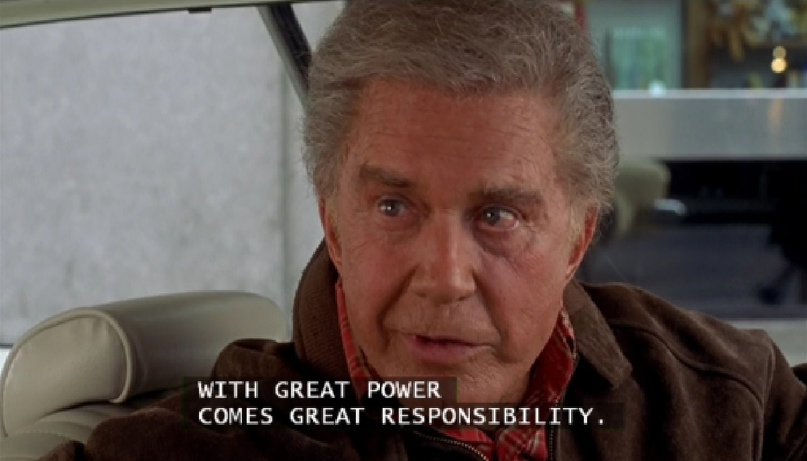

Один из способов - добровольно пожертвовать силой / гибкостью Python, а именно отказаться от неявности и явно указывать тип переменных, которые мы используем.

Тогда любая современная IDE сможет подсказать вам тип этой переменной.

## Type hints

Давайте сами указывать типы!

В современном Python это можно сделать с помощью аннотаций aka **type hints**:

In [ ]:
def hypot(a: float, b: float) -> float:
    return (a ** 2 + b ** 2) ** 0.5

Наведите курсор на скобочки ячейки ниже (подождите немного) и увидете аннотации аргументов и возвращаемого типа:

In [ ]:
hypot()

TypeError: hypot() missing 2 required positional arguments: 'a' and 'b'

Эти аннотации хранятся в атрибуте `__annotations__`:

In [ ]:
hypot.__annotations__

{'a': float, 'b': float, 'return': float}

Аналогично, можно добавлять аннотацию для переменных:

In [ ]:
var: float = 4.2

In [ ]:
var

## Typing

С простыми типами понятно, а что делать, если аргумент:
- является контейнером, но не понятно какой тип данных будет у его элементов?
- может быть не одним фиксированным типом, а одним из нескольких?
- может принимать значение `None`?


Здесь нам на помощь приходит модуль `typing`. Рассмотрим каждую из ситуаций:

### Контейнеры

Работа с контейнерами выглядит следующим образом:

In [ ]:
from typing import Dict, List, Tuple

names: List[str] = ["Guido", "Jukka", "Ivan"]
names_new: list[str] =  ["Guido", "Jukka", "Ivan"] # с недавних пор стало можно так!

version: Tuple[int, int, int] = (3, 7, 1)
version_new: tuple[int, int, int] = (3, 7, 1) # с недавних пор стало можно так!

options: Dict[str, bool] = {"centered": False, "capitalize": True}
options_new: dict[str, bool] = {"centered": False, "capitalize": True} # с недавних пор стало можно так!

Теперь всегда можем увидеть, что:

- `names` - список строк
- `version` - кортеж из 3х целых чисел
- `options` - словарь с строками в качестве ключей и булями в качестве значений

In [ ]:
version

Аналогично имеются `Counter`, `Deque`, `FrozenSet`, `NamedTuple` и `Set`.

>**Замечание** - списки и кортежи аннотируются по разному!
>
>Для списков указывается один тип - тип каждого из его элементов (`List[t]`), для кортежа указывается столько типов, сколько элементов он должен в себе содержать (`Tuple[t_1, t_2, ..., t_n]`)!

Аннотации могут быть и более сложными, например, список, элементами которого являются кортежи из двух чисел (координаты): `List[Tuple[float, float]]`

In [ ]:
points: List[Tuple[float, float]] = [
    (10.5, 20.3),
    (15.2, 25.7),
    (30.0, 40.0)
]


### Any

Как быть, если наш контейнер (например, список) может хранить элементы любого типа данных? Поможет `Any`:

In [ ]:
import random
from typing import List, Any

def choose(items: List[Any]) -> Any:
    return random.choice(items)

### Sequence

Часто функции ожидают не какой-то конкретный контейнер, а просто что-то, по чему можно пройтись циклом `for` и обработать элементы. В таких ситуациях полезна аннотация `Sequence`:

In [ ]:
from typing import List, Sequence

def square(elems: Sequence[float]) -> List[float]:
    return [x**2 for x in elems]

`Sequence` - любой тип, поддерживающий `len()` и `.__getitem__()`.

Часто приходится использовать одни и те же аннотации в разных функциях, каждый раз писать - неудобно. Благо, можно воспользоваться алиасами:

### Optional

Как быть с опциональными аргументами (со значением по умолчанию)? `Optional`!

`Optional` показывает, что аргумент либо является определенным типом, либо является `None`:

In [ ]:
from typing import Sequence, Optional

def player_order(
    names: Sequence[str], start: Optional[str] = None
) -> Sequence[str]:
    """Rotate player order so that start goes first"""
    if start is None:
        start = choose(names)
    start_idx = names.index(start)
    return names[start_idx:] + names[:start_idx]

In [ ]:
Coord = Tuple[float, float]
Points = List[Coord]

# Если функция ничего не должна возвращать, то можем указать None
def process_points(points: Points) -> None:
    for item in points:
        print(*item)

### Union

А если аргумент может быть одного типа из фиксированного множества? `Union`!

In [ ]:
from typing import Union

def debug(x: Union[int, float, str]) -> None:
    print(f"{x=}")

In [ ]:
# новый способ, без Union

def debug(x: int | float | str) -> None:
    print(f"{x=}")

In [ ]:
Optional[int] = ? = int | None == Union[int, None]

### Callable

Но как быть, если аргументом является функция? `Callable`!

`Callable[[arg1_type, arg2_type, ..., argn_type], output_type]`

In [ ]:
from typing import Callable

def do_twice(func: Callable[[str], str], argument: str) -> None:
    print(func(argument))
    print(func(argument))

def create_greeting(name: str) -> str:
    return f"Hello {name}"

do_twice(create_greeting, "Jekyll")

# Очень важная проблема!

Вспомним `list`

 Методы списка, вроде `len()`, `append()` и тд не требуют никаких знаний о том, что в этом списке лежит

И что теперь? Раз мы говорим, что типизация - круто, двайте делать **кучу копий** класса `list` с **абсолютно такими же** функциями, но **разными** принимаемыми типами?...



list[str] - написать класс

list[int] - написать класс 2
....

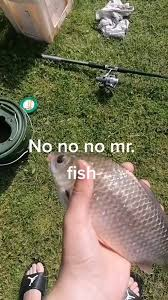

Давайте как-то объясним коду, что мы будем в этой функции работать с конкретным типом `Т`, но пока не знаем, с каким

 # Что такое дженерики?

Дженерик - параметризированный тип

## Дженерики и встроенные типы

Многие встроенные типы в Python являются дженериками:

In [ ]:
from typing import Set

# List - дженерик
names: List[str] = ["Alice", "Bob"]
names.append("Buba")

def append(item: str):
  pass

names: List[int] = [1, 1]
names.append(1)
def append(item: int):
  pass


# Dict - дженерик с двумя параметрами
scores: Dict[str, int] = {"Alice": 95, "Bob": 87}

# Set - дженерик
unique_ids: Set[int] = {1, 2, 3}

# Tuple - дженерик с фиксированным количеством параметров
point: Tuple[float, float] = (10.5, 20.3)

Можно делать свои дженерики!

## Синтаксис и основные компоненты

Собираем по частям

### TypeVar — переменная типа

In [ ]:
from typing import TypeVar

T = TypeVar('T')  # Простая переменная типа
K = TypeVar('K')  # Можно несколько
V = TypeVar('V')

# С ограничениями
Number = TypeVar('Number', int, float)  # Только int или float

### Функции с дженериками

In [ ]:
def first_element(items: List[T]) -> T:
    a: List[T] = items.copy()
    return items[0]

numbers = [1, 2, 3]
first_num: int = first_element(numbers)  # first_num - int
second_num: str = first_element(["1", "2", "3"])  # first_num - int

### Generic[T] — обобщенный класс

In [ ]:
from typing import Generic

class Stack(Generic[T]):  # Стек элементов типа T
    def __init__(self) -> None:
        self._items: List[T] = []

    def push(self, item: T) -> None:
        self._items.append(item)

    def pop(self) -> T:
        return self._items.pop()


str_stack = Stack[str]()

In [ ]:
str_stack.push("2")
str_stack.push(2)

## Инвариантность, Ковариантность и Контравариантность

In [ ]:
class Animal:
    def speak(self):
        return "Some sound"

class Dog(Animal):
    def speak(self):
        return "Woof!"
    def fetch(self):
        return "Fetching..."

class Cat(Animal):
    def speak(self):
        return "Meow!"

Мы можем использовать объект дочернего класса там, где ожидается объект родительского класса. То есть `Dog` — это частный случай `Animal`


(потому что дочерний класс РАСШИРЯЕТ функционал родительского)

**Инвариантность, Ковариантность и Контравариантность**

Эти слова описывают, как соотносятся типы сложных объектов (например, контейнеров `List[T]`), когда мы знаем соотношение типов их составных частей (параметров типа `T`).

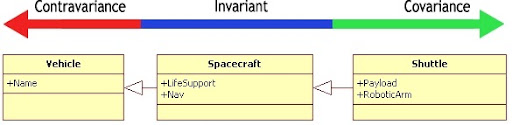

Пусть A -> B

- G[A] -> G[B], тогда G[T] - **КО**вариантен
- G[B] -> G[A], тогда G[T] - **КОНТРА**вариантен
- никак не соотносятся?    - **ИН**вариантен

#### Великое полезное знание


**Знание 1**

Cell magic (магические команды) в Jupyter — это специальные команды, начинающиеся с %%, которые применяются ко всей ячейке, а не к одной строке. Они расширяют функциональность Python, позволяя измерять время выполнения (%%time), писать код на других языках (например, %%bash, %%cython), строить графики или работать с файлами внутри одной ячейки

**Знание 2**

`mypy` — это статический анализатор типов для Python, который проверяет соответствие типов в вашем коде **без его выполнения**

**> Установка**

```
pip install mypy
```
**> Базовое использование**


```
mypy example.py
```




### Инвариантность

 Обычные изменяемые коллекции (как стандартный **list**) ведут себя инвариантно с точки зрения проверки типов.

In [ ]:
%%writefile invariance.py

from typing import List, get_type_hints

class Animal:
    def speak(self):
        return "Some sound"

class Dog(Animal):
    def speak(self):
        return "Woof!"
    def fetch(self):
        return "Fetching..."

class Cat(Animal):
    def speak(self):
        return "Meow!"

animal_list: List[Animal]
dog_list: List[Dog]

# A -> D

animal_list = dog_list

Overwriting invariance.py


In [ ]:
!mypy invariance.py

invariance.py:23: error: Incompatible types in assignment (expression has type "list[Dog]", variable has type "list[Animal]")  [assignment]
invariance.py:23: note: "list" is invariant -- see https://mypy.readthedocs.io/en/stable/common_issues.html#variance
invariance.py:23: note: Consider using "Sequence" instead, which is covariant
Found 1 error in 1 file (checked 1 source file)


In [ ]:
!pip install mypy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 107.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 5.6 MB/s eta 0:00:00


In [ ]:
%%writefile invariance.py

from typing import List

class Animal: pass
class Dog(Animal): pass
class Cat(Animal): pass

animal_list: List[Animal]
dog_list: List[Dog]

dog_list = animal_list

Overwriting invariance.py


In [ ]:
!mypy invariance.py

invariance.py:21: error: Incompatible types in assignment (expression has type "list[Animal]", variable has type "list[Dog]")  [assignment]
Found 1 error in 1 file (checked 1 source file)


### Ковариантность

Тип  `Sequence` - коваринатен

In [ ]:
%%writefile covariance.py
from typing import Sequence, List

class Animal: pass
class Dog(Animal): pass
class Cat(Animal): pass

animals: Sequence[Animal]
dog: Sequence[Dog]

# A -> D
animals = dog
# G[A] -> G[D] !!!!!!!

Overwriting covariance.py


In [ ]:
!mypy covariance.py

Success: no issues found in 1 source file


### Контравариантность

In [ ]:
%%writefile contravariance.py

from typing import Callable

class Animal: pass
class Dog(Animal): pass
class Puppy(Dog): pass

def handle_animal(a: Animal) -> str: return "animal"
def handle_dog(d: Dog) -> str: return "dog"
def handle_puppy(p: Puppy) -> str: return "cat"

def process_puppy(handler: Callable[[Dog], str], puppy: Puppy) -> str:
    return handler(puppy)

puppy = Puppy()

process_puppy(handle_animal, puppy)
process_puppy(handle_dog, puppy)
#process_puppy(handle_puppy, puppy)

# A -> D -> P
# G[P] -> G[D] -> G[A]

Overwriting contravariance.py


In [ ]:
!mypy contravariance.py

Success: no issues found in 1 source file


# Утиная типизация (Duck Typing) в Python

"Если это выглядит как утка, плавает как утка и крякает как утка, то это, вероятно, и есть утка"

(c) Конфуций

## Protocol в Python

In [ ]:
from typing import Protocol

class Quackable(Protocol): # Создаем крякательный объект
    def quack(self) -> str: ...
    # ... означает "тело не важно"

class Duck:
    def quack(self) -> str:
        return "Кря!"

class Dog:
    def quack(self) -> str:  # Собака тоже подходит!
        return "Гав? Кря?"

def make_it_quack(animal: Quackable) -> None: # нам подойдет всё что крякает
    print(animal.quack())

make_it_quack(Duck())  # OK
make_it_quack(Dog())   # OK (у Dog есть quack)

Кря!
Гав? Кря?


# Документация

Понять что делает тот или иной фрагмент кода - не всегда легко, даже если этот фрагмент писали вы сами, что уж говорить про других. А код читается намного чаще, чем пишется, поэтому важно упрощать не только процесс написания кода, но и процесс его чтения.

Основной способ - документирование кода, т.е. добавление сопроводительного материала, который рассказывает как именно работает код.

## Уровень 1. Комментарии в коде

Самый простой вариант - добавляйте в код комментарии, которые человеческим языком поясняют, что вокруг них происходит, например, что делает нижеидущий цикл или условие.

In [ ]:
students = [{"name": "Alex", "mark": 2}, {"name": "Bob", "mark": 4}]

# находим неуспевающих студентов
problematic_students = [student for student in students if student['mark'] <= 2]

>**Важно** - комментарий должен добавлять смысл в ваш код, а не просто его пересказывать!

## Уровень 2. Type hints

Про них мы сегодня говорили - они очень полезны при чтении кода. Не пренебрегайте ими!

Все аргументы и атрибуты по хорошему должны быть аннотированы!

## Уровень 3. Docstrings

Еще один встроенный способ документирования кода - docstrings, строки документации. Выглядят следующим образом:

In [ ]:
def function(number, kwarg=3):
    """
    Here lies docstring for this function
    """
    return kwarg

Данный докстринг отображается как в IDE при подсказках, так и при использовании функции `help`:

In [ ]:
help(function)

Help on function function in module __main__:

function(number, kwarg=3)
    Here lies docstring for this function



Существуют несколько форматов докстрингов:
- **Epytext** - от разработчиков [Epydoc](https://epydoc.sourceforge.net/)
- **reST** aka **reStructuredText** - от разработчиков [Sphinx](http://sphinx-doc.org/), используется в PyCharm
- **Google** - понятно от кого, ссылка на [формат](https://github.com/google/styleguide/blob/gh-pages/pyguide.md#38-comments-and-docstrings)
- **Numpydoc** - тоже понятно, ссылка на [формат](https://numpydoc.readthedocs.io/en/latest/)

Выберите один из них и придерживайтесь его :)

## Уровень 4. ChatGPT

Написание документации - часто утомительное дело, которое хотелось бы упростить. В этом вам могут помочь современные нейросетки :)

Но помните пару моментов:
1. Проверяйте работу сетки - может генерить полный бред
2. Не заливайте "чувствительный" код в публичные генеративные модели - например, код с работы, который находится под NDA (всегда спрашивайте разрешение у руководителей!)